In [1]:
from combine_data import combine_data
from datetime import datetime

from hamiltonian.base import HamiltonianParameters
from misc import data_folder
from solver.circuits import rebuild_ansatz
import h5py
from plotter import ResultLoader
from matplotlib import pyplot as plt
from numpyencoder import NumpyEncoder
import json
from misc import plots_folder
from pathlib import Path

In [2]:
output_filename = plots_folder
temp = "2025-09-35"
# output_filename += datetime.now().strftime('%Y-%m-%U')  #datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
output_filename += temp
Path(output_filename).mkdir(parents=True, exist_ok=True)  #todo
output_filename += "/"
output_filename

'results/plots/2025-09-35/'

In [3]:
combine_data()

-----Combining data-----
Skipping combined file 2025-08-34.hdf5
Skipping combined file 2025-09-35.hdf5
Skipping combined file 2025-08-33.hdf5
-----Finished combining data-----


In [4]:
h5_file = f"{data_folder}{datetime.now().strftime('%Y-%m-%U')}.hdf5"
h5_file = f"{data_folder}{temp}.hdf5"
h5_file

'results/data/2025-09-35.hdf5'

In [ ]:
global_info_dict = {}
with h5py.File(h5_file, "r") as f:
    for key, value in f.items():
        loader = ResultLoader(value)
        name, info_dict = loader.info_dict({})
        global_info_dict[name] = info_dict
with open(f"{output_filename}info.json", "w") as finfo:
    json.dump(global_info_dict, finfo, sort_keys=True, indent=4, cls=NumpyEncoder)

In [ ]:
with h5py.File(h5_file, "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
    vqe_1_loader = ResultLoader(f["2025-09-02_17-46-07"])
    vqe_1_energy, vqe_1_mass = vqe_1_loader.get_energy_mass({})
    vqe_2_loader = ResultLoader(f["2025-09-03_11-10-56"])
    vqe_2_energy, vqe_2_mass = vqe_2_loader.get_energy_mass({})
    vqe_3_loader = ResultLoader(f["2025-09-03_11-11-36"])
    vqe_3_energy, vqe_3_mass = vqe_3_loader.get_energy_mass({})
    vqe_4_loader = ResultLoader(f["2025-09-03_11-12-33"])
    vqe_4_energy, vqe_4_mass = vqe_4_loader.get_energy_mass({})

In [ ]:
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(vqe_1_mass, vqe_1_energy, label="VQE 4 layers 5000 iterations", marker='x', s=12, color='green')
ax.scatter(vqe_2_mass, vqe_2_energy, label="VQE 4 layers 20000 iterations", marker='.', s=12, color='purple')
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying iterations")
ax.legend()
fig.savefig(f"{output_filename}varying_iterations.png")
fig.savefig(f"{output_filename}varying_iterations.pdf")

In [ ]:
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(vqe_3_mass, vqe_3_energy, label="VQE 2 layers 20000 iterations", marker='x', s=10)
ax.scatter(vqe_2_mass, vqe_2_energy, label="VQE 4 layers 20000 iterations", marker='.', color='purple', s=12)
ax.scatter(vqe_4_mass, vqe_4_energy, label="VQE 8 layers 20000 iterations", marker='.', color='green', s=12)
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying layer count")
ax.legend()
fig.savefig(f"{output_filename}varying_layer_count.png")
fig.savefig(f"{output_filename}varying_layer_count.pdf")

ParameterView([ParameterVectorElement(phi[0]), ParameterVectorElement(phi[1]), ParameterVectorElement(phi[2]), ParameterVectorElement(phi[3]), ParameterVectorElement(phi[4]), ParameterVectorElement(phi[5]), ParameterVectorElement(phi[6]), ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17]), ParameterVectorElement(θ[18]), ParameterVectorElement(θ[19]), ParameterVectorElement(θ[20]), ParameterVectorElement(θ[21]), ParameterVectorElement(θ[22])])


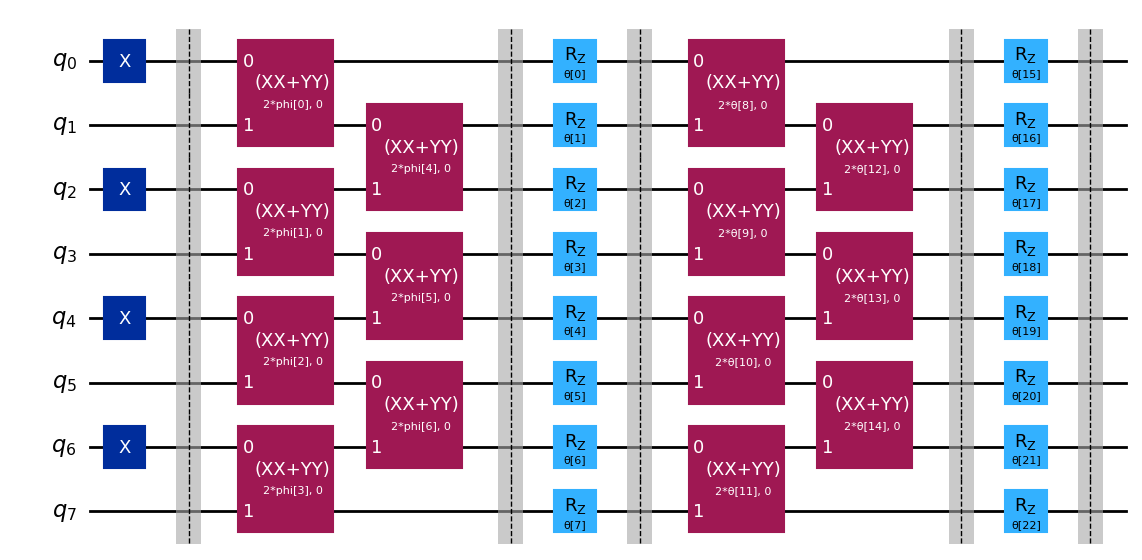

In [5]:
with h5py.File(h5_file, "r") as f:
    circuit = rebuild_ansatz(f["2025-09-03_11-10-56"])
    circuit = rebuild_ansatz(f["2025-09-03_11-11-36"])
    # circuit = rebuild_ansatz(f["2025-09-03_11-12-33"])
print(circuit.full_ansatz.parameters)
circuit.full_ansatz.draw("mpl", filename=f"{output_filename}circuit-2-layer.pdf")

ParameterView([ParameterVectorElement(phi[0]), ParameterVectorElement(phi[1]), ParameterVectorElement(phi[2]), ParameterVectorElement(phi[3]), ParameterVectorElement(phi[4]), ParameterVectorElement(phi[5]), ParameterVectorElement(phi[6]), ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17]), ParameterVectorElement(θ[18]), ParameterVectorElement(θ[19]), ParameterVectorElement(θ[20]), ParameterVectorElement(θ[21]), ParameterVectorElement(θ[22])])


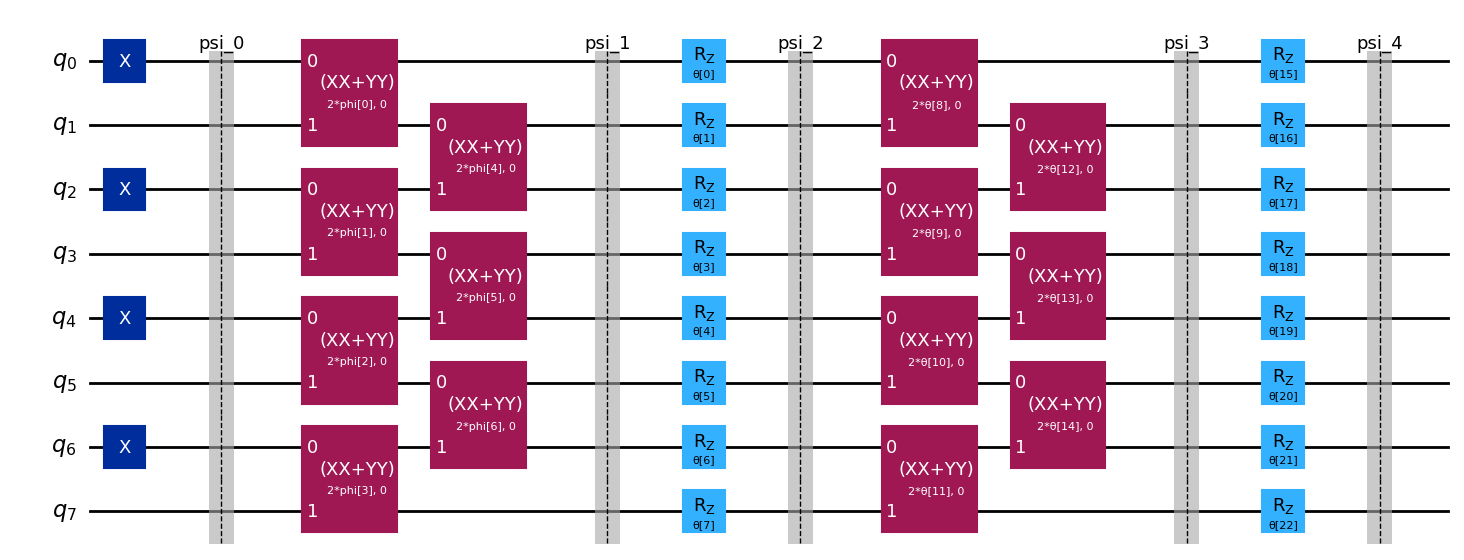

In [7]:
temp = circuit.build_full_ansatz_with_save_points()
print(temp.parameters)
temp.draw("mpl")

In [ ]:
with h5py.File(h5_file, "r") as f:
    vqe_1_loader = ResultLoader(f["2025-09-03_11-10-56"])
    vqe_1_energy, vqe_1_mass = vqe_1_loader.get_energy_mass({})
    vqe_2_loader = ResultLoader(f["2025-09-06_15-50-13"])
    vqe_2_energy, vqe_2_mass = vqe_2_loader.get_energy_mass({})
    vqe_3_loader = ResultLoader(f["2025-09-06_15-50-13-23147802"])
    vqe_3_energy, vqe_3_mass = vqe_3_loader.get_energy_mass({})
    vqe_4_loader = ResultLoader(f["2025-09-06_15-50-13-23147804"])
    vqe_4_energy, vqe_4_mass = vqe_4_loader.get_energy_mass({})
    vqe_5_loader = ResultLoader(f["2025-09-06_15-50-13-23147805"])
    vqe_5_energy, vqe_5_mass = vqe_5_loader.get_energy_mass({})
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1, color="black")
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1, color="gray")
ax.scatter(vqe_1_mass, vqe_1_energy, label="1 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_2_mass, vqe_2_energy, label="2 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_3_mass, vqe_3_energy, label="3 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_4_mass, vqe_4_energy, label="4 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.scatter(vqe_5_mass, vqe_5_energy, label="5 VQE 4 layers 20000 iterations", marker='.', s=12)
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying seeds")
ax.legend()
fig.savefig(f"{output_filename}varying_seeds.png")
fig.savefig(f"{output_filename}varying_seeds.pdf")

In [ ]:
import numpy as np


def count_differences(labels: list[str]):
    base_label = "10101010"
    diffs = []
    for label in labels:
        if label:
            temp = 0
            for posit, letter in enumerate(label):
                if letter == base_label[posit]:
                    pass
                else:
                    temp += 1
            diffs.append(temp)
    return diffs


plt.rcParams['figure.constrained_layout.use'] = True
with h5py.File(h5_file, "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    for pos in range(0, 1000, 100):
        print(f"Mass = {ed_mass[pos]:.2f}:")
        gs_fig, gs_labels = ed_loader.plot_ground_state({HamiltonianParameters.Mass: pos})
        gs_diffs = count_differences(gs_labels)
        print("GS", np.sum(gs_diffs), gs_diffs)
        gs_fig.savefig(f"{output_filename}gs_m_{ed_mass[pos]:.2f}.png")
        plt.close(gs_fig)

        es_fig, es_labels = ed_loader.plot_excited_state({HamiltonianParameters.Mass: pos})
        es_diffs = count_differences(es_labels)
        print("ES", np.sum(es_diffs), es_diffs)
        es_fig.savefig(f"{output_filename}es_m_{ed_mass[pos]:.2f}.png")
        plt.close(es_fig)

In [ ]:
with h5py.File(h5_file, "r") as f:
    vqe_5_loader = ResultLoader(f["2025-09-06_15-50-13-23147805"])
    vqe_5_energy, vqe_5_mass = vqe_5_loader.get_energy_mass({})